In [ ]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn xgboost joblib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

warnings.filterwarnings("ignore")

from google.colab import files

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor

In [ ]:
uploaded = files.upload()

file_name = "swim_simulated_performance.csv"

df = pd.read_csv(file_name)

df.head()

Saving swim_simulated_performance.csv to swim_simulated_performance.csv


,id,name,sex,nationality,height,weight,age_2024,distance_m,sim_pace_sec_per_100m,sim_time_sec
0,382571888,Aaron Younger,male,AUS,1.93,100.0,33,400,61.31,245.25
1,382571888,Aaron Younger,male,AUS,1.93,100.0,33,800,66.62,533.00
2,382571888,Aaron Younger,male,AUS,1.93,100.0,33,200,56.99,113.98
3,162792594,Abbey Weitzeil,female,USA,1.78,68.0,28,1500,66.59,998.83
4,162792594,Abbey Weitzeil,female,USA,1.78,68.0,28,400,60.53,242.12


In [ ]:
print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicates:")
print(df.duplicated().sum())

df.describe()

Dataset shape: (2787, 10)

Columns:
Index(['id', 'name', 'sex', 'nationality', 'height', 'weight', 'age_2024',
       'distance_m', 'sim_pace_sec_per_100m', 'sim_time_sec'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2787 entries, 0 to 2786
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     2787 non-null   int64  
 1   name                   2787 non-null   object 
 2   sex                    2787 non-null   object 
 3   nationality            2787 non-null   object 
 4   height                 2787 non-null   float64
 5   weight                 2787 non-null   float64
 6   age_2024               2787 non-null   int64  
 7   distance_m             2787 non-null   int64  
 8   sim_pace_sec_per_100m  2787 non-null   float64
 9   sim_time_sec           2787 non-null   float64
dtypes: float64(4), int64(3), object(3)
memory usage: 217.9+ KB

M

,id,height,weight,age_2024,distance_m,sim_pace_sec_per_100m,sim_time_sec
count,2.787000e+03,2787.000000,2787.000000,2787.000000,2787.000000,2787.00000,2787.000000
mean,5.062003e+08,1.789354,72.473269,31.893793,725.511302,61.38226,462.163168
std,2.832314e+08,0.109740,14.260558,4.349525,495.469839,4.38565,335.390602
min,3.545330e+05,1.430000,39.000000,22.000000,200.000000,48.69000,97.390000
25%,2.616300e+08,1.700000,61.000000,29.000000,400.000000,57.89500,208.735000
50%,5.063250e+08,1.780000,71.000000,31.000000,800.000000,61.53000,467.080000
75%,7.543166e+08,1.870000,83.000000,35.000000,800.000000,64.80500,561.155000
max,9.987105e+08,2.210000,130.000000,49.000000,1500.000000,75.73000,1135.940000


In [ ]:
df = df.drop_duplicates()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

print("After cleaning:", df.shape)
print(df.isnull().sum())

After cleaning: (2787, 10)
id                       0
name                     0
sex                      0
nationality              0
height                   0
weight                   0
age_2024                 0
distance_m               0
sim_pace_sec_per_100m    0
sim_time_sec             0
dtype: int64


In [ ]:
df["height_m"] = df["height"] / 100

df["BMI"] = df["weight"] / (df["height_m"] ** 2)

def distance_category(distance):
    if distance <= 100:
        return "Sprint"
    elif distance <= 400:
        return "Middle"
    else:
        return "Long"

df["distance_category"] = df["distance_m"].apply(distance_category)

df.head()

,id,name,sex,nationality,height,weight,age_2024,distance_m,sim_pace_sec_per_100m,sim_time_sec,height_m,BMI,distance_category
0,382571888,Aaron Younger,male,AUS,1.93,100.0,33,400,61.31,245.25,0.0193,268463.582915,Middle
1,382571888,Aaron Younger,male,AUS,1.93,100.0,33,800,66.62,533.00,0.0193,268463.582915,Long
2,382571888,Aaron Younger,male,AUS,1.93,100.0,33,200,56.99,113.98,0.0193,268463.582915,Middle
3,162792594,Abbey Weitzeil,female,USA,1.78,68.0,28,1500,66.59,998.83,0.0178,214619.366242,Long
4,162792594,Abbey Weitzeil,female,USA,1.78,68.0,28,400,60.53,242.12,0.0178,214619.366242,Middle


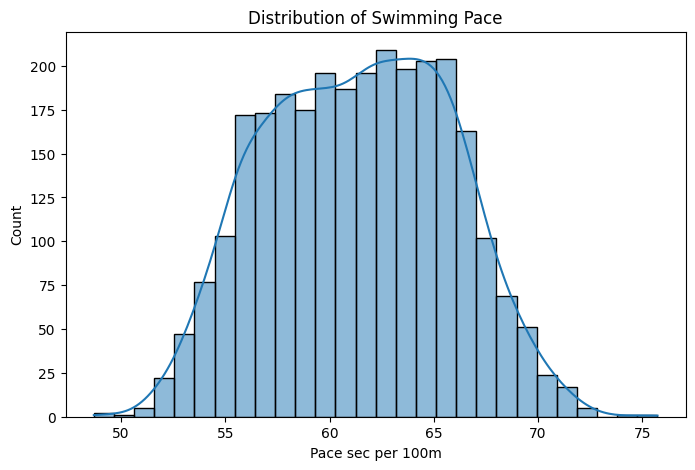

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(df["sim_pace_sec_per_100m"], kde=True)
plt.title("Distribution of Swimming Pace")
plt.xlabel("Pace sec per 100m")
plt.ylabel("Count")
plt.show()

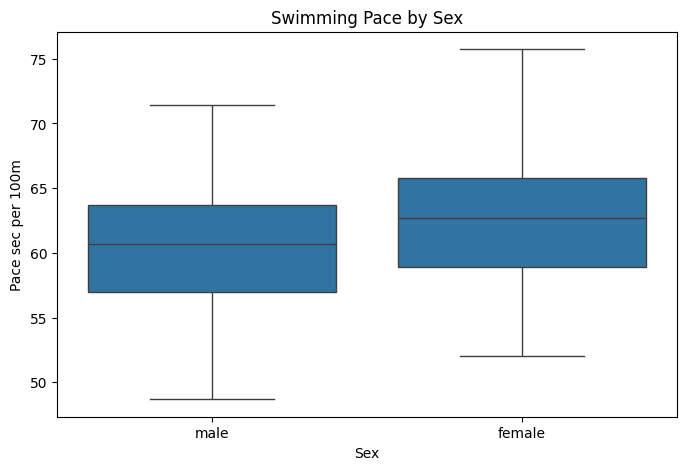

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="sex", y="sim_pace_sec_per_100m", data=df)
plt.title("Swimming Pace by Sex")
plt.xlabel("Sex")
plt.ylabel("Pace sec per 100m")
plt.show()

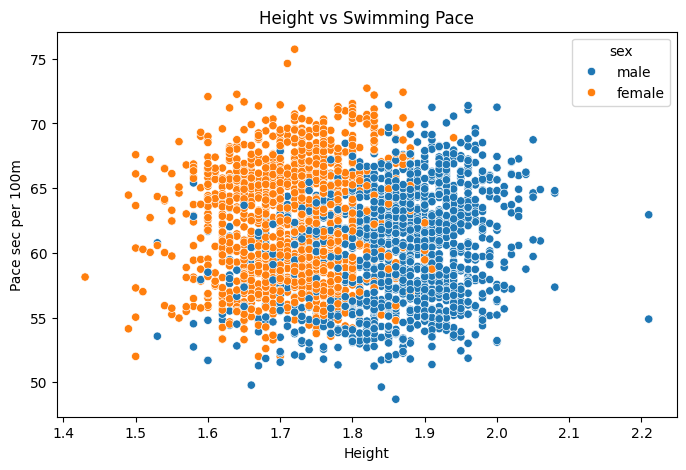

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="height",
    y="sim_pace_sec_per_100m",
    hue="sex",
    data=df
)
plt.title("Height vs Swimming Pace")
plt.xlabel("Height")
plt.ylabel("Pace sec per 100m")
plt.show()

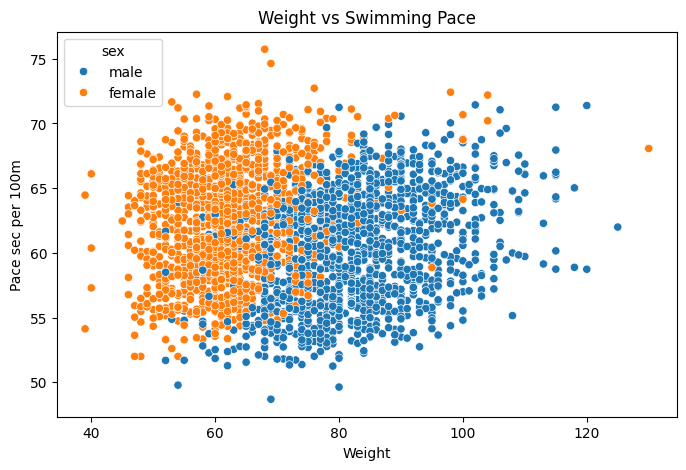

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x="weight",
    y="sim_pace_sec_per_100m",
    hue="sex",
    data=df
)
plt.title("Weight vs Swimming Pace")
plt.xlabel("Weight")
plt.ylabel("Pace sec per 100m")
plt.show()

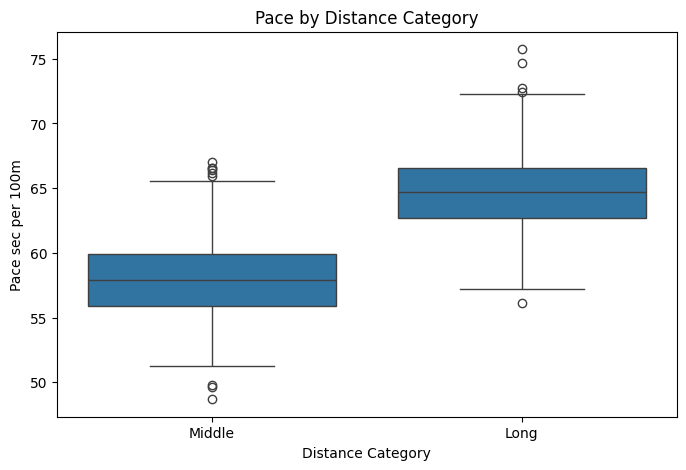

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    x="distance_category",
    y="sim_pace_sec_per_100m",
    data=df
)
plt.title("Pace by Distance Category")
plt.xlabel("Distance Category")
plt.ylabel("Pace sec per 100m")
plt.show()

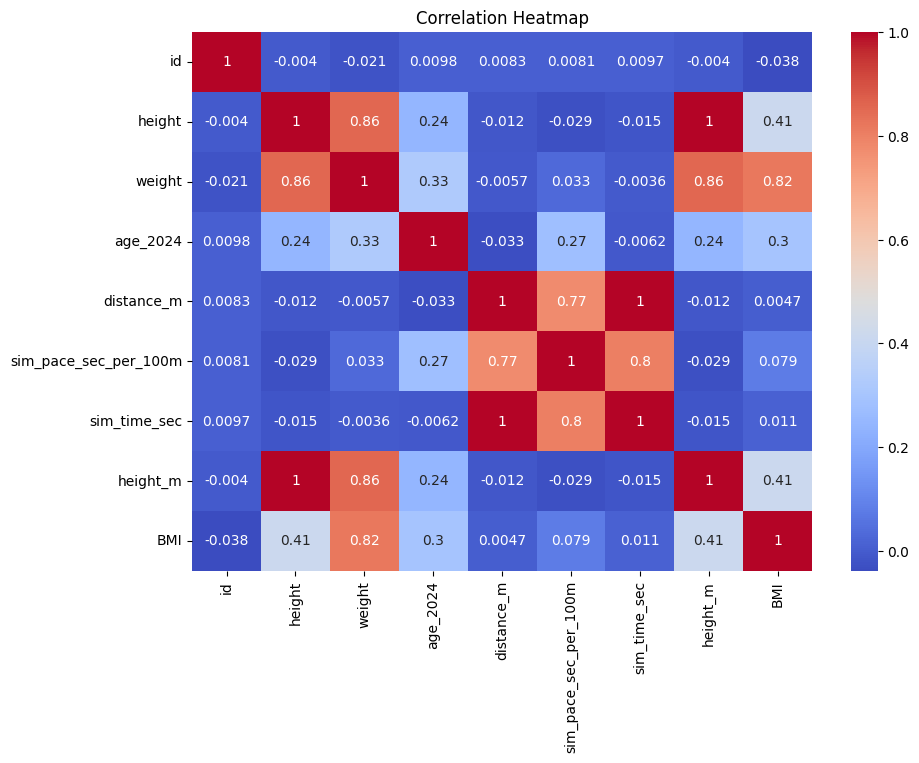

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10, 7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
target = "sim_pace_sec_per_100m"

In [ ]:
X = df.drop(
    columns=[
        "sim_pace_sec_per_100m",
        "sim_time_sec",
        "id",
        "name"
    ],
    errors="ignore"
)

y = df[target]

print("Features:")
print(X.columns)

print("\nTarget:")
print(target)

Features:
Index(['sex', 'nationality', 'height', 'weight', 'age_2024', 'distance_m',
       'height_m', 'BMI', 'distance_category'],
      dtype='object')

Target:
sim_pace_sec_per_100m


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (2229, 9)
X_test: (558, 9)
y_train: (2229,)
y_test: (558,)


In [ ]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

Categorical features: ['sex', 'nationality', 'distance_category']
Numeric features: ['height', 'weight', 'age_2024', 'distance_m', 'height_m', 'BMI']


In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    )
}

results = []

for model_name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append(
        {
            "Model": model_name,
            "MAE": mae,
            "RMSE": rmse,
            "R2 Score": r2
        }
    )

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="R2 Score", ascending=False)

results_df

,Model,MAE,RMSE,R2 Score
3,Gradient Boosting,1.304682,1.625068,0.858064
2,Random Forest,1.341691,1.673281,0.849517
4,XGBoost,1.386640,1.723091,0.840425
0,Linear Regression,1.413509,1.778799,0.829940
1,Decision Tree,1.699032,2.111962,0.760271


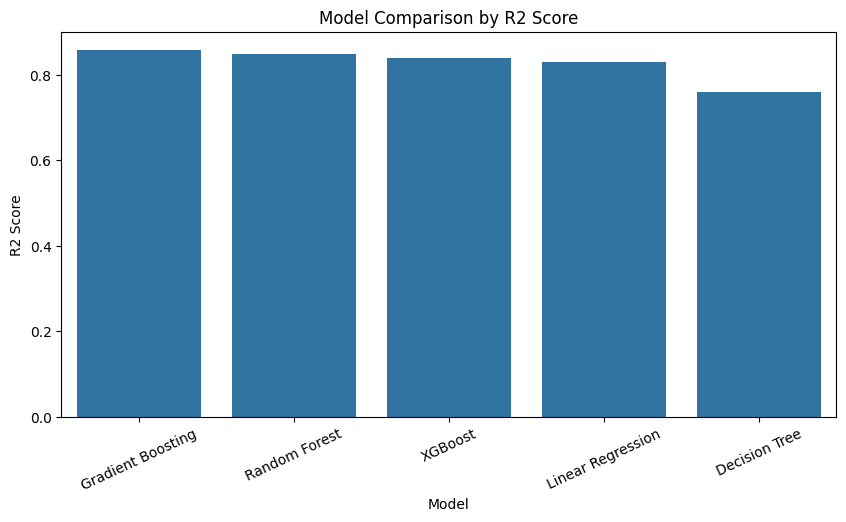

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="R2 Score", data=results_df)
plt.xticks(rotation=25)
plt.title("Model Comparison by R2 Score")
plt.show()

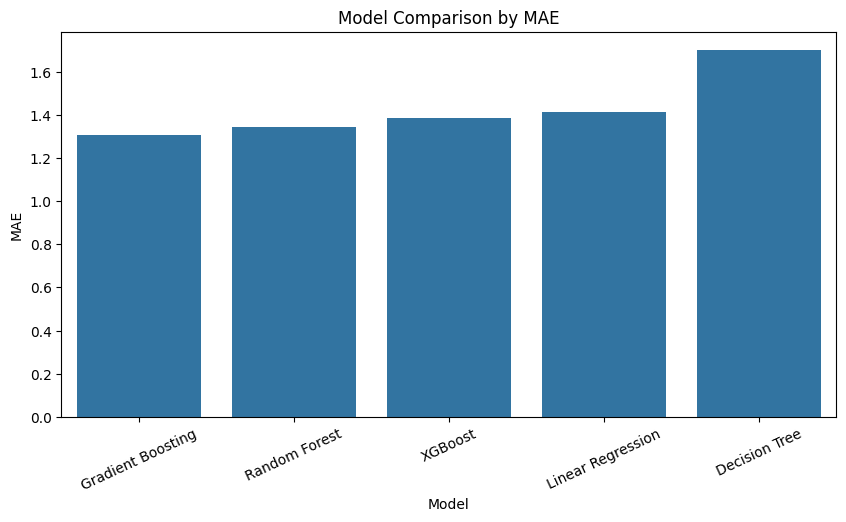

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(x="Model", y="MAE", data=results_df)
plt.xticks(rotation=25)
plt.title("Model Comparison by MAE")
plt.show()

In [ ]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ]
)

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest CV R2 score:")
print(grid_search.best_score_)

Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 5, 'model__n_estimators': 200}

Best CV R2 score:
0.8653881005206167


In [ ]:
best_model = grid_search.best_estimator_

final_predictions = best_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_predictions)
final_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
final_r2 = r2_score(y_test, final_predictions)

print("Final Model Results")
print("MAE:", final_mae)
print("RMSE:", final_rmse)
print("R2 Score:", final_r2)

Final Model Results
MAE: 1.310354911757258
RMSE: 1.634827100178523
R2 Score: 0.8563542413582779


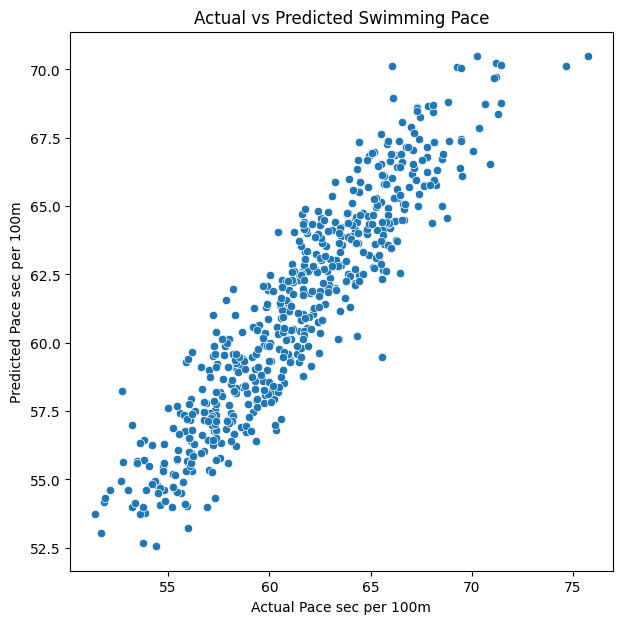

In [ ]:
plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=final_predictions)

plt.xlabel("Actual Pace sec per 100m")
plt.ylabel("Predicted Pace sec per 100m")
plt.title("Actual vs Predicted Swimming Pace")

plt.show()

In [ ]:
error_df = pd.DataFrame(
    {
        "Actual": y_test,
        "Predicted": final_predictions,
        "Error": y_test - final_predictions,
        "Absolute Error": np.abs(y_test - final_predictions)
    }
)

error_df = error_df.sort_values(by="Absolute Error", ascending=False)

error_df.head(10)

,Actual,Predicted,Error,Absolute Error
2537,65.56,59.477146,6.082854,6.082854
218,52.74,58.221190,-5.481190,5.481190
436,75.73,70.484506,5.245494,5.245494
544,74.63,70.114662,4.515338,4.515338
1737,70.92,66.529571,4.390429,4.390429
2651,68.75,64.559980,4.190020,4.190020
564,64.32,60.247404,4.072596,4.072596
829,66.06,70.124298,-4.064298,4.064298
927,66.47,62.570784,3.899216,3.899216
2642,57.21,61.027366,-3.817366,3.817366


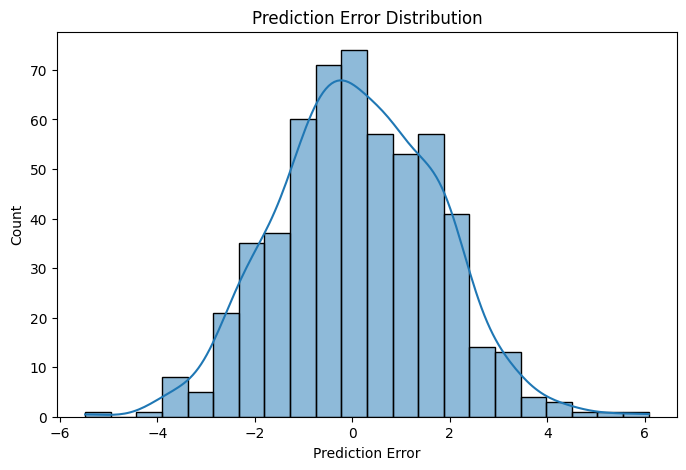

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(error_df["Error"], kde=True)
plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Count")
plt.show()

In [ ]:
rf_model = best_model.named_steps["model"]

feature_names = []

feature_names.extend(numeric_features)

onehot = (
    best_model
    .named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["onehot"]
)

categorical_names = onehot.get_feature_names_out(categorical_features)

feature_names.extend(categorical_names)

importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": rf_model.feature_importances_
    }
)

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
3,distance_m,0.305275
162,distance_category_Long,0.251379
163,distance_category_Middle,0.145789
2,age_2024,0.116002
1,weight,0.046759
6,sex_female,0.035228
7,sex_male,0.032014
5,BMI,0.023799
4,height_m,0.007522
0,height,0.007323


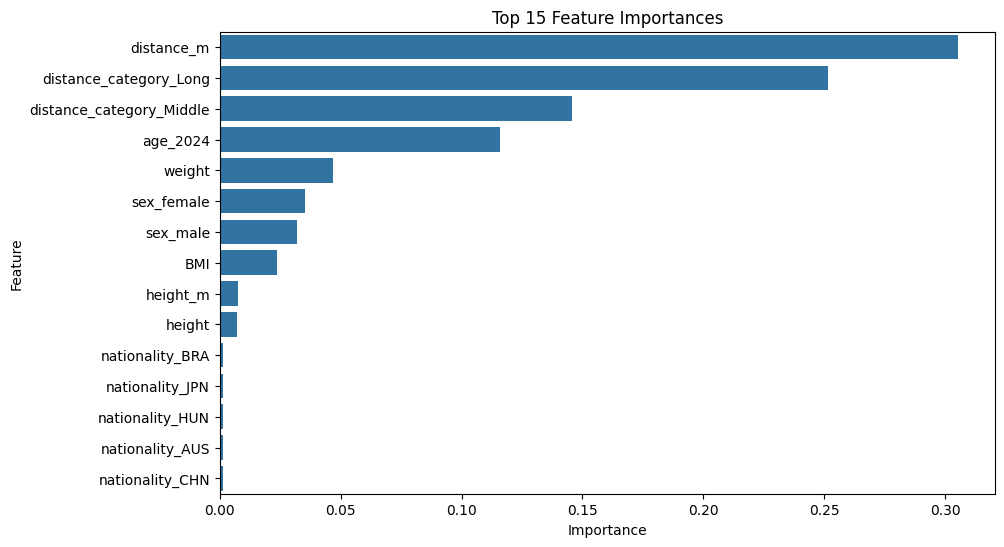

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(15)
)

plt.title("Top 15 Feature Importances")
plt.show()

In [ ]:
joblib.dump(best_model, "swimming_pace_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [ ]:
sample = X_test.iloc[[0]]

prediction = best_model.predict(sample)[0]

print("Input:")
display(sample)

print("Predicted Pace sec per 100m:", prediction)
print("Actual Pace sec per 100m:", y_test.iloc[0])

Input:


,sex,nationality,height,weight,age_2024,distance_m,height_m,BMI,distance_category
2079,male,TUN,1.92,84.0,40,400,0.0192,227864.583333,Middle


Predicted Pace sec per 100m: 61.92231402694533
Actual Pace sec per 100m: 59.92


In [ ]:
files.download("swimming_pace_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

st.title("Biometric-Based Swimming Pace Prediction")

st.write(
    "This application predicts swimming pace per 100 meters "
    "based on biometric and race-related features."
)

model = joblib.load("swimming_pace_model.pkl")

sex = st.selectbox("Sex", ["Male", "Female"])
nationality = st.text_input("Nationality", "USA")

height = st.number_input(
    "Height in cm",
    min_value=100.0,
    max_value=230.0,
    value=180.0
)

weight = st.number_input(
    "Weight in kg",
    min_value=30.0,
    max_value=150.0,
    value=75.0
)

age_2024 = st.number_input(
    "Age",
    min_value=10,
    max_value=60,
    value=22
)

distance_m = st.selectbox(
    "Distance in meters",
    [50, 100, 200, 400, 800, 1500]
)

height_m = height / 100
BMI = weight / (height_m ** 2)

if distance_m <= 100:
    distance_category = "Sprint"
elif distance_m <= 400:
    distance_category = "Middle"
else:
    distance_category = "Long"

input_data = pd.DataFrame(
    {
        "sex": [sex],
        "nationality": [nationality],
        "height": [height],
        "weight": [weight],
        "age_2024": [age_2024],
        "distance_m": [distance_m],
        "height_m": [height_m],
        "BMI": [BMI],
        "distance_category": [distance_category]
    }
)

if st.button("Predict Swimming Pace"):
    predicted_pace = model.predict(input_data)[0]
    predicted_time = predicted_pace * distance_m / 100

    st.success(f"Predicted pace: {predicted_pace:.2f} sec per 100m")
    st.info(f"Estimated total race time: {predicted_time:.2f} sec")

    st.write("Input data:")
    st.dataframe(input_data)

Overwriting app.py


In [ ]:
!pip install -q streamlit

In [ ]:
!npm install -g localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸
added 22 packages in 4s
⠸
⠸3 packages are looking for funding
⠸  run `npm fund` for details
⠸

In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!lt --port 8501

your url is: https://violet-islands-kiss.loca.lt
